# **Pull GitHub Repository**

In [1]:
!pip install -q torchmetrics timm

In [2]:
from google.colab import userdata

!rm -rf /content/ECM3401_Individual_Project

token = userdata.get('GitHub')
!git clone -b swin_transformer_layer https://{token}@github.com/sccthomas/ECM3401_Individual_Project.git

Cloning into 'ECM3401_Individual_Project'...
remote: Enumerating objects: 1742, done.
remote: Counting objects: 100% (325/325), done.
remote: Compressing objects: 100% (203/203), done.
remote: Total 1742 (delta 222), reused 214 (delta 122), pack-reused 1417 (from 1)
Receiving objects: 100% (1742/1742), 3.47 MiB | 30.13 MiB/s, done.
Resolving deltas: 100% (1184/1184), done.


In [3]:
import sys

sys.path.append('/content/ECM3401_Individual_Project/')
!ls /content/ECM3401_Individual_Project/src/

dataset  __init__.py  self_supervised_learning	training  vision_transformer


# **Define the Model**

In [4]:
import torch
from src.vision_transformer.model.three_scales import SemanticSegmentationVisionTransformer

# --------------------------------------------
# Parameters
# --------------------------------------------

device = torch.device("cuda")
metric_device = torch.device("cpu")

image_dims = (3, 512, 512)  # Input image dimensions
patch_embedding_scale_1 = (32, 1024)  # Patch size and embedding dimension for scale 1
patch_embedding_scale_2 = (16, 768)  # Patch size and embedding dimension for scale 2
patch_embedding_scale_3 = (8, 512)  # Patch size and embedding dimension for scale 3

# --------------------------------------------
# Model Initialization
# --------------------------------------------
model = SemanticSegmentationVisionTransformer(
    # - Image dimensions
    image_dims=image_dims,
    # - Hyper Parameters
    num_encoder_layers=6,
    use_heavyweight_decoder=False,
    use_swin_transformer=False,
    use_skip_layer_gated_attention=False,
    skip_layer_ratio=2,
    encoder_dropout_rate=0.15,
    patch_fusion_dropout_rate=0.25,
    decoder_dropout_rate=0.25,
    num_encoder_heads=8,
    num_classes=1,
    # - Scales
    patch_embedding_scale_1=patch_embedding_scale_1,
    patch_embedding_scale_2=patch_embedding_scale_2,
    patch_embedding_scale_3=patch_embedding_scale_3,
).to(device)

# **Train the Model**

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from src.dataset.snow import SnowDataset
from src.training.train import train_model

import os as _os

_os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
# --------------------------------------------
# Parameters
# --------------------------------------------
dataset_dir = "/content/drive/MyDrive/snow_dataset"  # Replace with your dataset path
batch_size = 15
num_epochs = 10
learning_rate = 1e-4
patience = 5  # Early stopping patience

# --------------------------------------------
# Dataset and DataLoader
# --------------------------------------------

# Load the dataset and split it into train and validation sets
train_dataset = SnowDataset(
    dataset_dir_path=dataset_dir,
    len_override=10_000,
    normalize=True,
)
print(len(train_dataset))
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=10,
    persistent_workers=True,
    pin_memory=True,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=10,
    persistent_workers=True,
    pin_memory=True,
)

# --------------------------------------------
# Loss, Optimizer, and Scheduler
# --------------------------------------------
criterion = nn.BCEWithLogitsLoss()  # Binary cross-entropy loss with logits
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)  # Use CosineAnnealingLR scheduler

# --------------------------------------------
# Mixed Precision Setup
# --------------------------------------------
scaler = torch.amp.GradScaler(device.type)

# --------------------------------------------
# Train Model
# --------------------------------------------
train_model(
    model=model,
    num_epochs=num_epochs,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    scaler=scaler,
    train_loader=train_loader,
    val_loader=val_loader,
    patience=patience,
    device=device,
    metric_device=metric_device,
)

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 15 worker processes in total. Our suggested max number of worker in current system is 12, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


10000

 Epoch 1/10


Training: 100%|██████████| 534/534 [22:01<00:00,  2.48s/it]


------- Training Metrics -------
--------------------------------------------
Average Binary Cross Entropy Loss: 0.32772008887725823 
Average Dice Score: 0.5905340392602964 
Average Mean IoU: 0.44514046002472385 
--------------------------------------------



Validation: 100%|██████████| 134/134 [02:13<00:00,  1.01it/s]


...

------- Validation Metrics -------
--------------------------------------------
Average Binary Cross Entropy Loss: 0.10609150455513996 
Average Dice Score: 0.8252960114336726 
Average Mean IoU: 0.7047494792226535 
--------------------------------------------


 Epoch 10/10


Training: 100%|██████████| 534/534 [12:53<00:00,  1.45s/it]


------- Training Metrics -------
--------------------------------------------
Average Binary Cross Entropy Loss: 0.10729923280660579 
Average Dice Score: 0.8234845326187905 
Average Mean IoU: 0.7006058750974105 
--------------------------------------------



Validation: 100%|██████████| 134/134 [01:06<00:00,  2.02it/s]


------- Validation Metrics -------
--------------------------------------------
Average Binary Cross Entropy Loss: 0.10585330782541588 
Average Dice Score: 0.8252482374212635 
Average Mean IoU: 0.7046928592582247 
--------------------------------------------



In [8]:
!cp /content/best_model.pth /content/drive/MyDrive/best_model.pth

# **Evaluate the Model**

In [5]:
import torch

# Load the model's state_dict (replace 'model.pth' with your file name)
# model.load_state_dict(torch.load('/content/drive/MyDrive/best_model_scale_3.pth'))
model.load_state_dict(torch.load('best_model.pth'))
model = model.eval()

<ipython-input-5-5347b803e2c5>:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_model.pth'))


In [6]:
from src.dataset.snow import SnowDataset
from torch.utils.data import DataLoader

dataset_dir = "/content/drive/MyDrive/snow_dataset"  # Replace with your dataset path

# Dataset and DataLoader
batch_size = 10

train_dataset = SnowDataset(
    dataset_dir_path=dataset_dir,
    len_override=30,
    normalize=True,
)
validation_dataset = SnowDataset(
    dataset_dir_path=dataset_dir,
    len_override=30,
    normalize=False,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=1,
)
val_loader = DataLoader(
    validation_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=1,
)

In [7]:
# Get predictions
images, masks = next(iter(train_loader))
images, masks = images.to(device), masks.to(device)
outputs, _ = model(images)

# Get non-normalized images for evaluation
images_original, _ = next(iter(val_loader))

In [8]:
import torch.nn as nn

criterion = nn.BCEWithLogitsLoss()  # Binary cross-entropy loss with logits
loss = criterion(outputs, masks)
print(loss)
del loss
del criterion

tensor(0.1065, device='cuda:0',
       grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)


In [9]:
from src.training.visualisation import display_attention_weights, display_tensor_mask, display_tensor_image

outputs = torch.sigmoid(outputs)
image_idx = 0

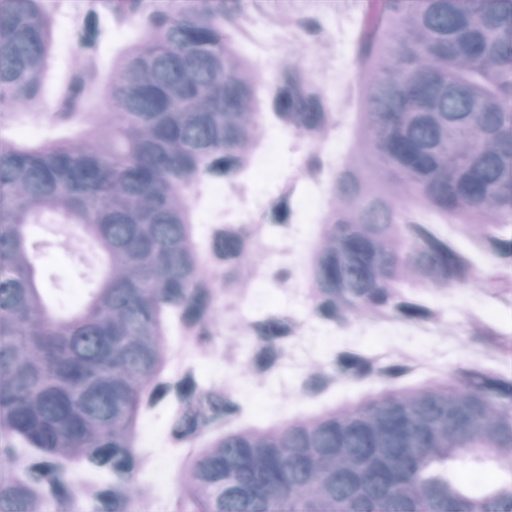

In [10]:
display_tensor_image(images_original[image_idx])

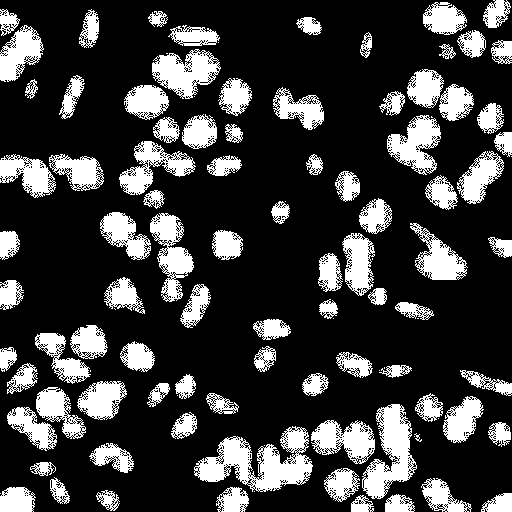

In [11]:
display_tensor_mask(masks[image_idx])

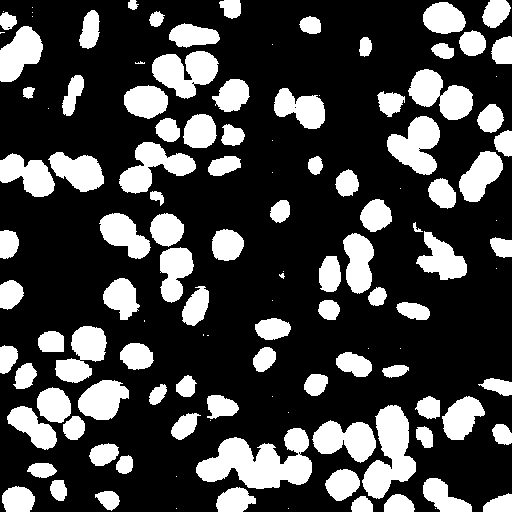

In [12]:
display_tensor_mask(outputs[image_idx] > 0.5)

In [13]:
del masks, outputs

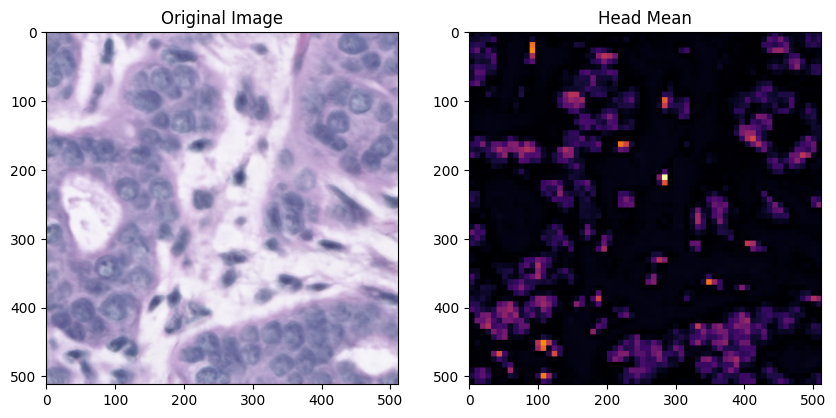

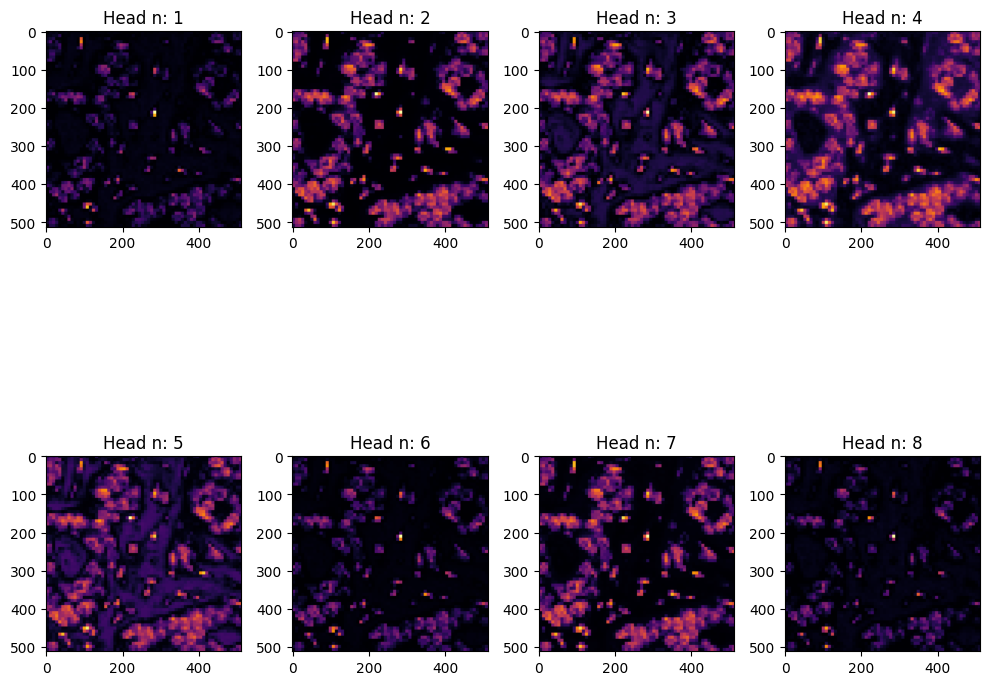

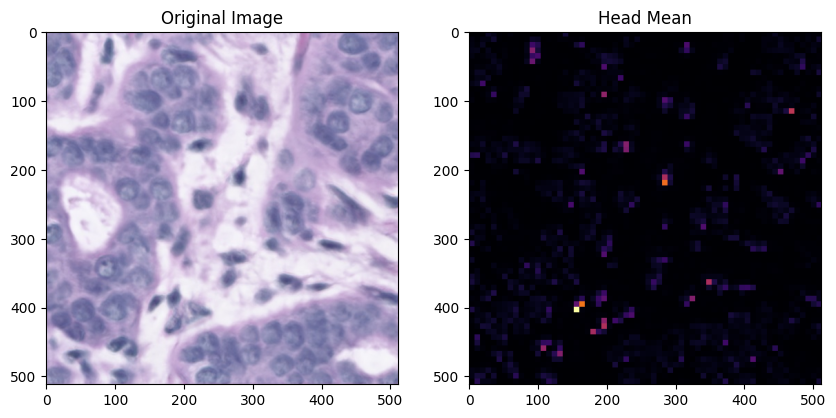

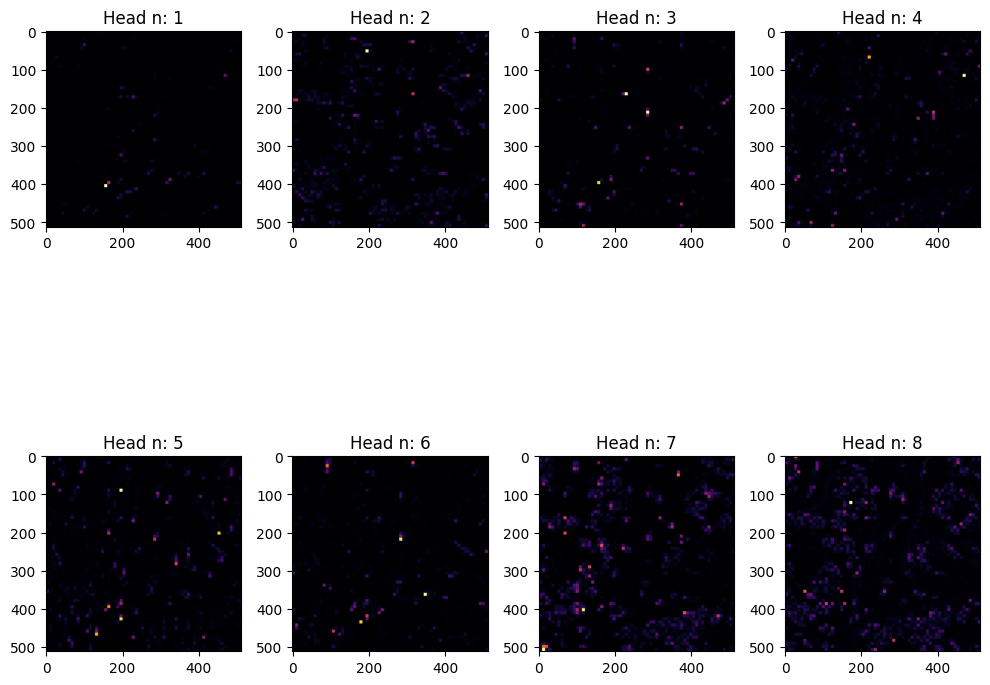

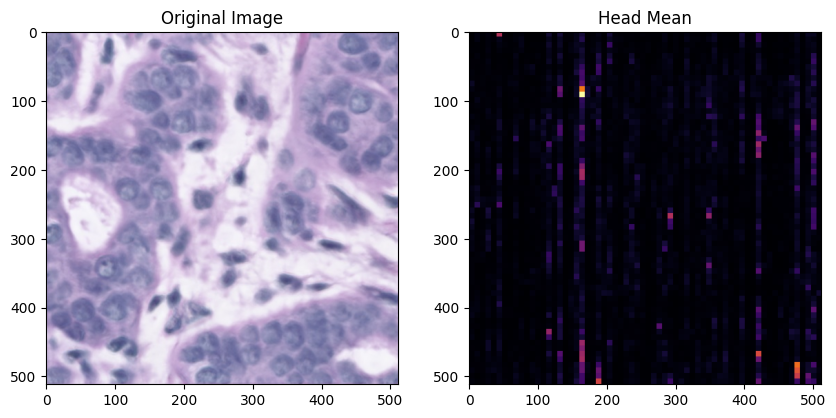

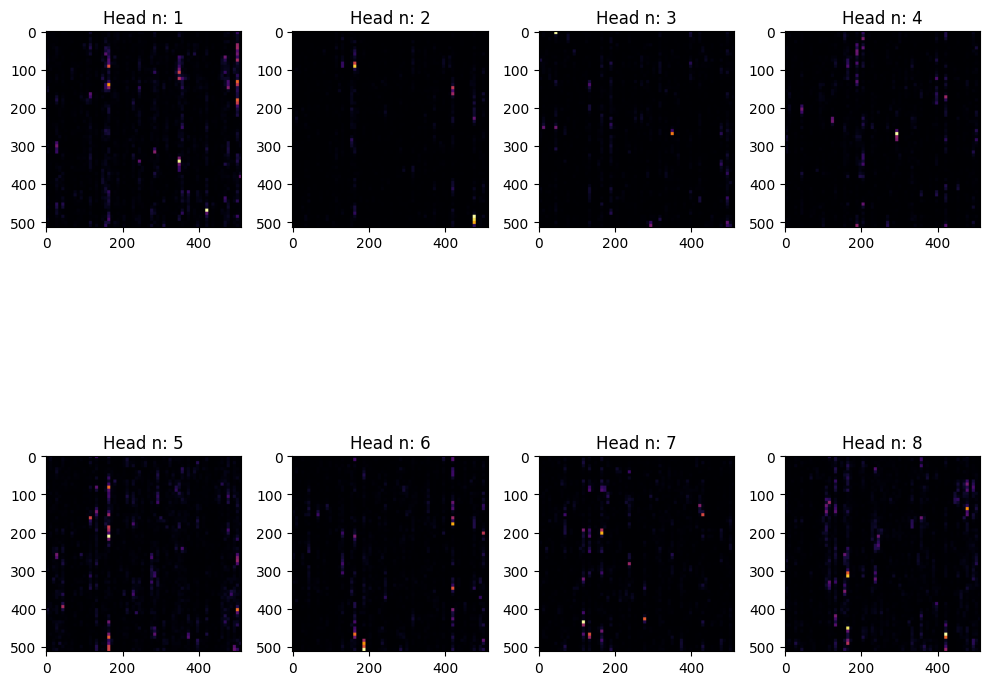

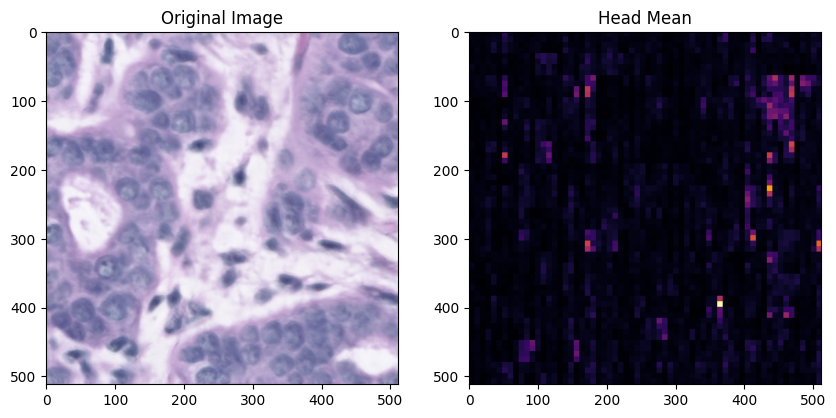

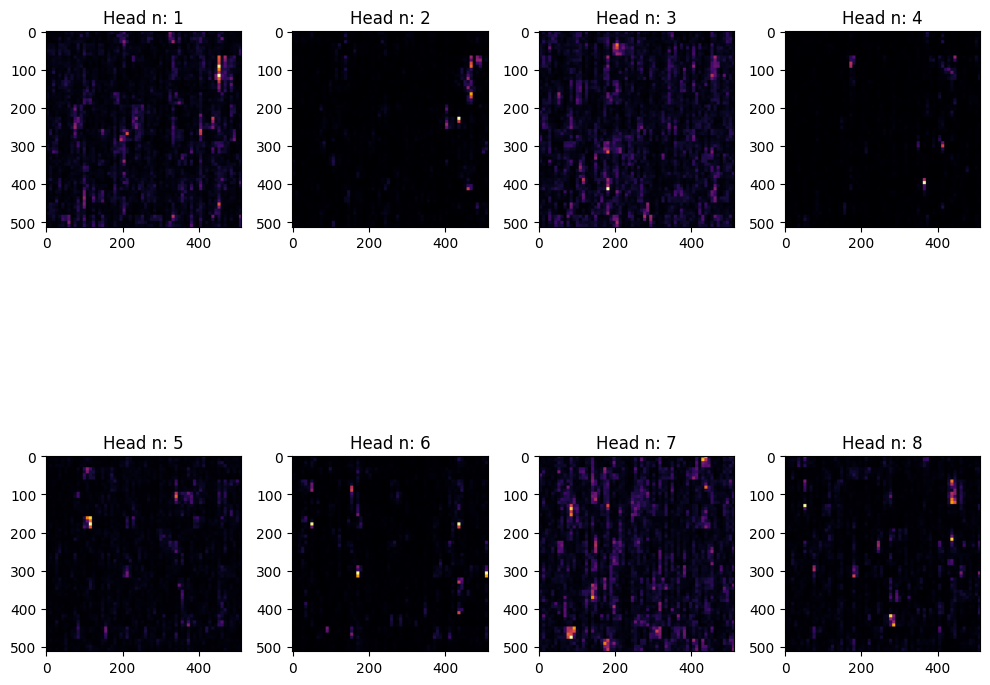

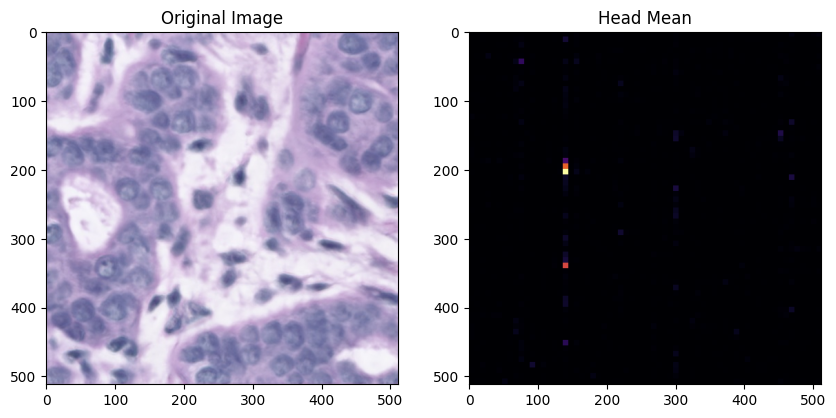

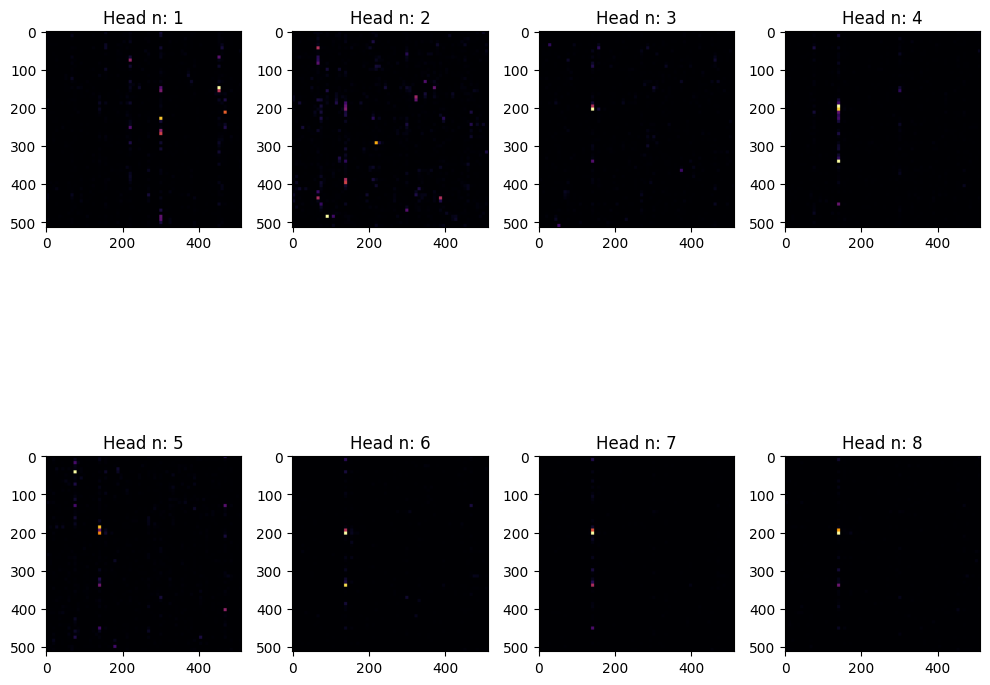

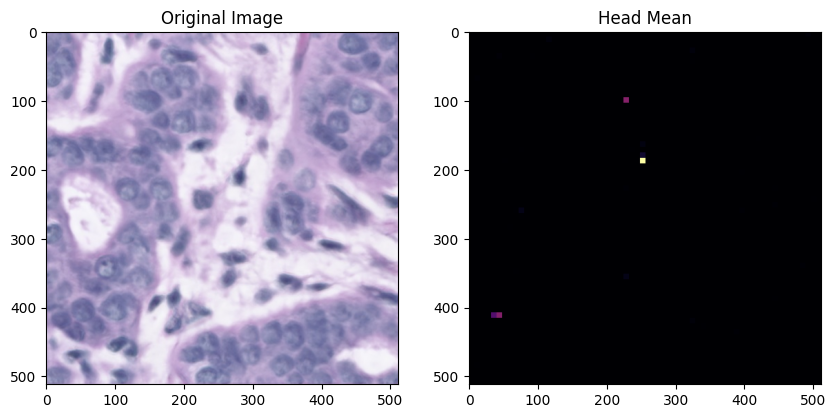

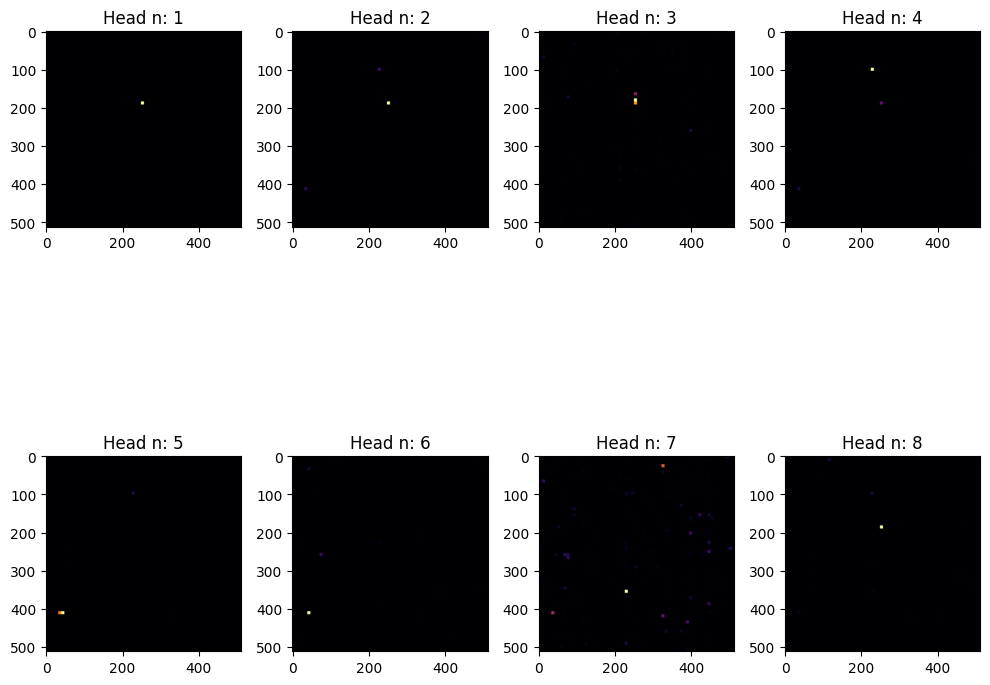

In [14]:
for i in range(6):
    display_attention_weights(model, images_original[0], images[0], 8, 'x3', i, True)